In [79]:
# !pip install ipywidgets

In [ ]:
import os
from pathlib import Path
import amulet
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter

random.seed(1984)



blocks_counter = Counter()

directory = Path("../../data/")

files = [directory / "train" / file  for file in os.listdir(directory / "train")] + \
    [directory / "new_train" / file for file in os.listdir(directory / "new_train")]
random.shuffle(files)

limit = len(files)

for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = file
    try:
        construction = amulet.load_level(str(path))
        dimension = construction.dimensions[0]
        selection = construction.bounds(dimension)
        for coords in selection.blocks:
            block = construction.get_block(*coords, dimension)
            blocks_counter[block.base_name] += 1
    except Exception as e:
        print()
        print(path)
        print(e)



In [82]:
print(f"Total blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

Total blocks: 199
Total amount: 1326534979
20 Most common:
('air', 773106967)
('stone', 199231915)
('water', 159206600)
('dirt', 68970173)
('leaves', 22784219)
('grass_block', 20860194)
('sand', 12786186)
('sandstone', 11164474)
('andesite', 5355447)
('stained_terracotta', 5221685)
('diorite', 5213107)
('granite', 5096926)
('terracotta', 4663477)
('gravel', 4544074)
('packed_ice', 3190483)
('log', 3093803)
('plant', 2862268)
('coal_ore', 2787606)
('deepslate', 2651586)
('snow', 2223133)


In [83]:
minus_counter = Counter({key: -value for key, value in blocks_counter.items()})

minus_counter.most_common(20)

[('stained_glass', -1),
 ('sculk_shrieker', -1),
 ('coal_block', -2),
 ('hanging_roots', -3),
 ('smithing_table', -4),
 ('polished_basalt', -4),
 ('wall_sign', -4),
 ('jack_o_lantern', -4),
 ('sculk_catalyst', -6),
 ('lever', -7),
 ('carved_pumpkin', -8),
 ('smoker', -9),
 ('cracked_deepslate_tiles', -9),
 ('fletching_table', -9),
 ('cobbled_deepslate', -10),
 ('barrel', -11),
 ('lectern', -13),
 ('redstone_torch', -13),
 ('raw_iron_block', -13),
 ('campfire', -13)]

In [84]:
world_blocks_counter = blocks_counter
world_block_set = set(blocks_counter.keys())

Разобраться с дефольными атрибутами и зафиксировать финальный набор

Глянуть распределение атрибутов в мирах

Несколько вариантов кодирования блоков + атрибутов

СОхранить json всех блоков

# Раскинуть файлы по папкам

In [2]:
import os
from pathlib import Path
from tqdm import tqdm
import os

data_dir = Path("../../data/web_data/")


extensions = [".schematic", ".schem", ".litematic"]

In [ ]:
for ex in extensions:
    os.makedirs(data_dir / ex[1:], exist_ok=True)


for file in os.listdir(data_dir):
    file_path = data_dir / file
    if file_path.suffix in extensions:
        os.rename(file_path, data_dir / file_path.suffix[1:] / file)

## запустил скрипты


In [ ]:
for file in tqdm(os.listdir(data_dir / "litematic")):
    file_path = data_dir / "litematic" / file
    if file_path.suffix == ".schem":
        os.rename(file_path, data_dir / "schem" / file)

100%|██████████| 4064/4064 [00:08<00:00, 463.05it/s]


In [11]:
count = 0
for file in tqdm(os.listdir(data_dir / "schematic")):
    file_path = data_dir / "schematic" / file
    if file_path.suffix == ".schem":
        count += 1
        os.rename(file_path, data_dir / "schem" / file)
print(count)

100%|██████████| 11215/11215 [00:00<00:00, 144811.05it/s]

4


In [8]:
import nbtlib


schem = nbtlib.load(data_dir / "schem_py_2" / "100.schem")

In [17]:
schem["Schematic"]["Length"]

Short(30)

In [18]:
schem = nbtlib.load(data_dir / "schem" / "100.schem")

In [19]:
schem.keys()

dict_keys(['Version', 'DataVersion', 'Width', 'Height', 'Length', 'Palette', 'BlockData'])

## считаем статистики по schem_all mc schematics

In [ ]:
import os
from pathlib import Path
import amulet
import json
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter
from logging import Logger
import numpy as np

random.seed(1984)
np.random.seed(1984)

with open("../block_data/filtered_blocks.json") as f:
    filtered_blocks = json.load(f)


blocks_counter = Counter()
non_existing_blocks_fraction = []

directory = Path("../../data/web_data/schem_all")

shapes = []

files = os.listdir(directory)
np.random.shuffle(files)

limit = len(files)

success_count = 0
for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = directory / file
    try:
        non_existing_blocks_count = 0
        construction = amulet.load_level(str(path))
        dimension = construction.dimensions[0]
        selection = construction.bounds(dimension)
        bounds_array = selection.bounds_array
        shape = np.abs(bounds_array[0] - bounds_array[1])

        for coords in selection.blocks:
            block = construction.get_block(*coords, dimension).base_name
            if f"minecraft:{block}" in filtered_blocks:
                blocks_counter[block] += 1
            else:
                blocks_counter["air"] += 1
                non_existing_blocks_count += 1

        shapes.append(shape[None, :])
        non_existing_blocks_fraction.append(non_existing_blocks_count / np.prod(shape))
        success_count += 1
        construction.close()
    except Exception as e:
        print(f"Error: {e}\nFile: {file}")
        continue

shapes = np.concatenate(shapes, axis=0)

In [2]:
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

2012

In [4]:
print(f"Successfully opened: {success_count} / {limit} schematics")
print(f"Allowed size schematics: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1))}")
print(f"Schematics with less than 10% of non-existing blocks: {np.sum(non_existing_blocks_fraction < 0.1)}")
print(f"Final schematics count: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1) * (non_existing_blocks_fraction < 0.1))}")

Successfully opened: 3202 / 3368 schematics
Allowed size schematics: 1723
Schematics with less than 10% of non-existing blocks: 2012
Final schematics count: 942


In [9]:
np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1) * (non_existing_blocks_fraction < 0.1)) / success_count

0.2941911305434104

In [3]:
print(f"Min x,y,z: {shapes.min(axis = 0)}")
print(f"Max x,y,z: {shapes.max(axis = 0)}")
print(f"Mean x,y,z: {shapes.mean(axis = 0)}")
print(f"Median x,y,z: {np.median(shapes,axis=0)}")

Min x,y,z: [8 8 8]
Max x,y,z: [701 384 802]
Mean x,y,z: [55.99367089 48.39389427 55.95085629]
Median x,y,z: [34. 30. 33.]


In [4]:
volumes: np.ndarray = np.prod(shapes, axis=1)

print(f"Min Volume: {volumes.min()}")
print(f"Max Volume: {volumes.max()}")
print(f"Mean Volume: {volumes.mean()}")
print(f"Median Volume: {np.median(volumes)}")

Min Volume: 512
Max Volume: 76562780
Mean Volume: 787324.2271034996
Median Volume: 35695.0


In [5]:
print(f"Uniqie blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

Uniqie blocks: 296
Total amount: 2102356103
20 Most common:
('air', 1922235719)
('stone', 70670320)
('dirt', 26055799)
('water', 16632143)
('sandstone', 5654289)
('andesite', 5042665)
('cobblestone', 4884978)
('grass_block', 4306725)
('stone_bricks', 4226111)
('diorite', 3357897)
('granite', 3156999)
('gravel', 2139741)
('sand', 2017379)
('quartz_block', 1845150)
('coarse_dirt', 1562523)
('smooth_stone', 1531513)
('netherrack', 1463573)
('nether_portal', 1389186)
('obsidian', 1194821)
('smooth_quartz', 1146389)


In [6]:
print(f"20 Least common:")

minus_counter = Counter({key: -value for key, value in blocks_counter.items()})

minus_counter.most_common(20)

20 Least common:


[('smooth_quartz_slab', -9),
 ('candle_cake', -10),
 ('calibrated_sculk_sensor', -13),
 ('sculk_shrieker', -18),
 ('smooth_quartz_stairs', -18),
 ('sculk_catalyst', -20),
 ('conduit', -32),
 ('pitcher_crop', -67),
 ('sculk_sensor', -116),
 ('respawn_anchor', -136),
 ('bamboo_sapling', -137),
 ('medium_amethyst_bud', -180),
 ('crimson_fungus', -183),
 ('light_weighted_pressure_plate', -193),
 ('nether_sprouts', -212),
 ('powder_snow', -229),
 ('mangrove_propagule', -234),
 ('warped_roots', -249),
 ('suspicious_sand', -253),
 ('twisting_vines', -258)]

In [91]:
web_blocks_counter = blocks_counter
web_blocks_set = set(web_blocks_counter.keys())

In [92]:
world_blocks_counter
world_block_set;

In [93]:
print(f"Web blocks: {len(web_blocks_set)}")
print(f"World blocks: {len(world_block_set)}")
print(f"Common blocks: {len(web_blocks_set & world_block_set)}")

Web blocks: 297
World blocks: 199
Common blocks: 165


In [94]:
mask = shapes < np.array([64, 64, 64])[None, :]
mask = np.prod(mask.astype(np.int32), axis=1)

print(f"Shapes in 64^3: {mask.sum()} / {limit}")

Shapes in 64^3: 2167 / 3368


In [19]:
2167 - 523

1644

In [14]:
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

In [8]:
len(non_existing_blocks_fraction[non_existing_blocks_fraction < 0.1])

2012

In [7]:
len(non_existing_blocks_fraction[non_existing_blocks_fraction < 0.2])

2728

In [20]:
len(non_existing_blocks_fraction)


2680

In [22]:
len(shapes)

2686

In [ ]:
# (non_existing_blocks_fraction < 0.2) * np.prod(shapes[:2680] < 64, axis=1)

array([0.00499418, 0.12522727, 0.10289668, ..., 0.01669484, 0.00744048,
       0.01752904])

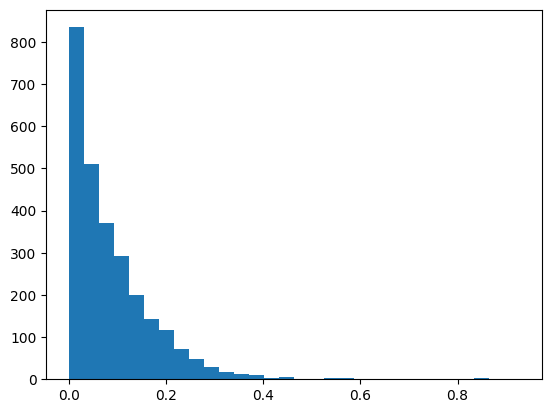

In [ ]:
import matplotlib.pyplot as plt

plt.hist(non_existing_blocks_fraction, bins=30);

In [11]:
# from pathlib import Path

# # litematic = os.listdir("../../data/web_data/litematic")

# schematics_ids = list(map(lambda x: Path(x).stem,os.listdir("../../data/web_data/schematic")))

# for file in tqdm(os.listdir("../../data/web_data/schem_all")):
#     file = Path(file)
#     if file.stem in schematics_ids:
#         os.rename("../../data/web_data/schem_all/" / file, "../../data/web_data/schem_done/" / file)
#     # print(file)

100%|██████████| 12815/12815 [00:25<00:00, 503.62it/s]


Глянуть пересечение по блокам между множествами

Сделать фильтр на число заменямых блкоов на воздух (10% грань)

Пофильтровать по минимальному объему

Глянукть сколько сэмплов умешается в 64х64х64



# Статистика по трейну

In [ ]:
import torch
import json
from pathlib import Path
import os


block_data_path = Path("../block_data/")
data_dir = Path("../../data/dataset/")

with open(block_data_path / "idx2block.json") as f:
    idx2block = json.load(f)
    
files = [data_dir / "train" / file for file in os.listdir(data_dir / "train")] + \
    [data_dir / "val" / file for file in os.listdir(data_dir / "val")] + \
    [data_dir / "train_extended" / file for file in os.listdir(data_dir / "train_extended")] + \
    [data_dir / "val_extended" / file for file in os.listdir(data_dir / "val_extended")]

In [ ]:
from tqdm import tqdm

result = {block : 0 for block in idx2block}

for file in tqdm(files):
    block_type = torch.load(file / "block_type.pt", weights_only=False)
    for idx in block_type.flatten():
        result[idx2block[idx]] += 1
        
with open("statistics.json", "w") as w:
    json.dump(result, w, indent=4)

In [1]:
import json
import matplotlib.pyplot as plt

with open("../block_data/statistics.json") as f:
    statistics = json.load(f)

statistics = list(statistics.items())

In [2]:
import numpy as np
import torch

values = torch.from_numpy(np.array([x[1] for x in statistics])).float()
values = values[values > 0]
np.sum(np.array([x[1] for x in statistics]) < 10000)

800

In [3]:
len(statistics)

972

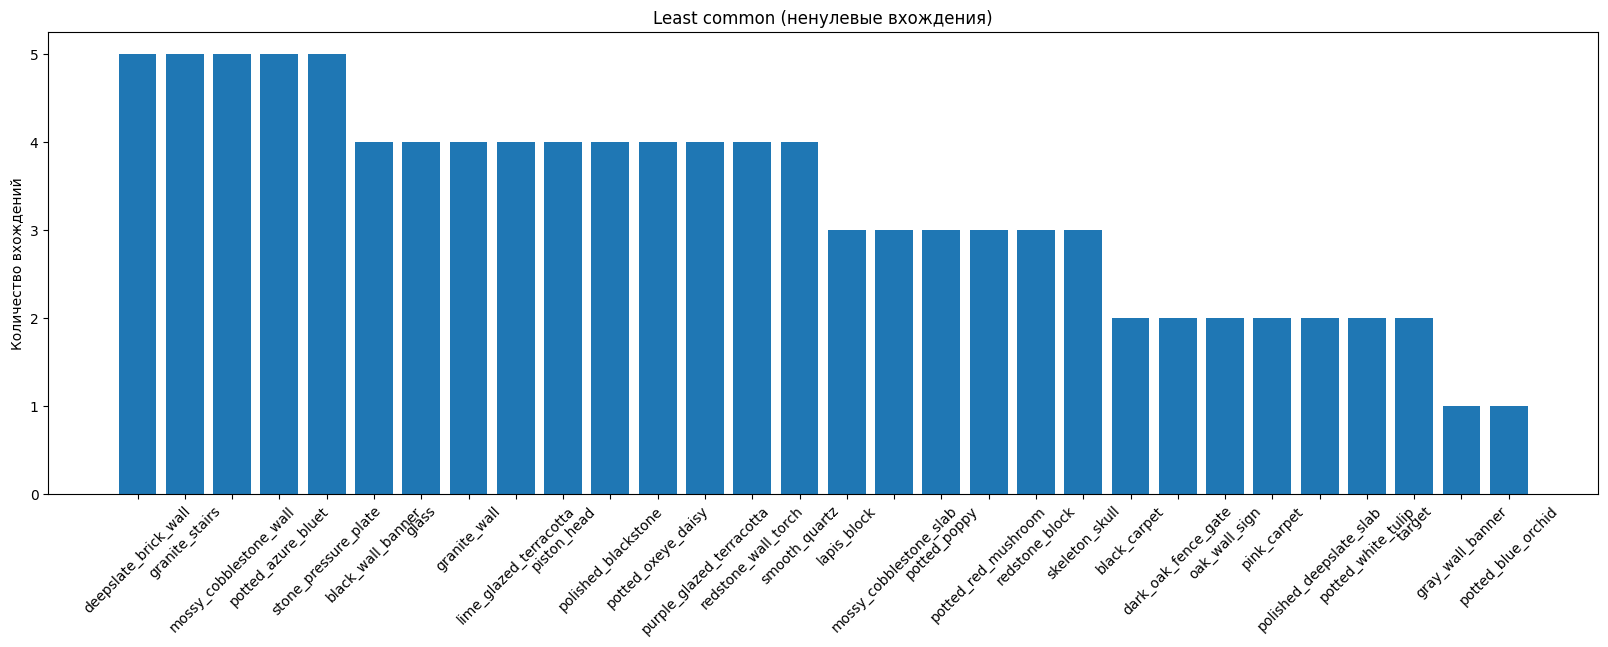

In [4]:
import numpy as np

def show_top_statistics(statistics, limit, reversed=False, nonzero=False, ax=None, title=""):
    data = sorted(statistics, key=lambda x: -x[1])

    if nonzero:
        data = [item for item in data if item[1] != 0]

    if reversed:
        data = data[-limit:]
    else:
        data = data[:limit]


    names = [item[0][item[0].index(":") + 1:] for item in data]
    values = [item[1] for item in data]

    ax.bar(np.arange(len(names)), values)
    ax.set_xticks(np.arange(len(names)), names, rotation=45)
    ax.set_title(title)
    ax.set_ylabel("Количество вхождений")
    # ax.set_yscale("log")

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# show_top_statistics(statistics, 300, reversed=True, nonzero=False, ax=ax[0], title="Least common")
show_top_statistics(statistics, 30, reversed=True, nonzero=True, ax=ax, title="Least common (ненулевые вхождения)")
# show_top_statistics(statistics, 15, reversed=False, nonzero=False, ax=ax[1], title="Most common")

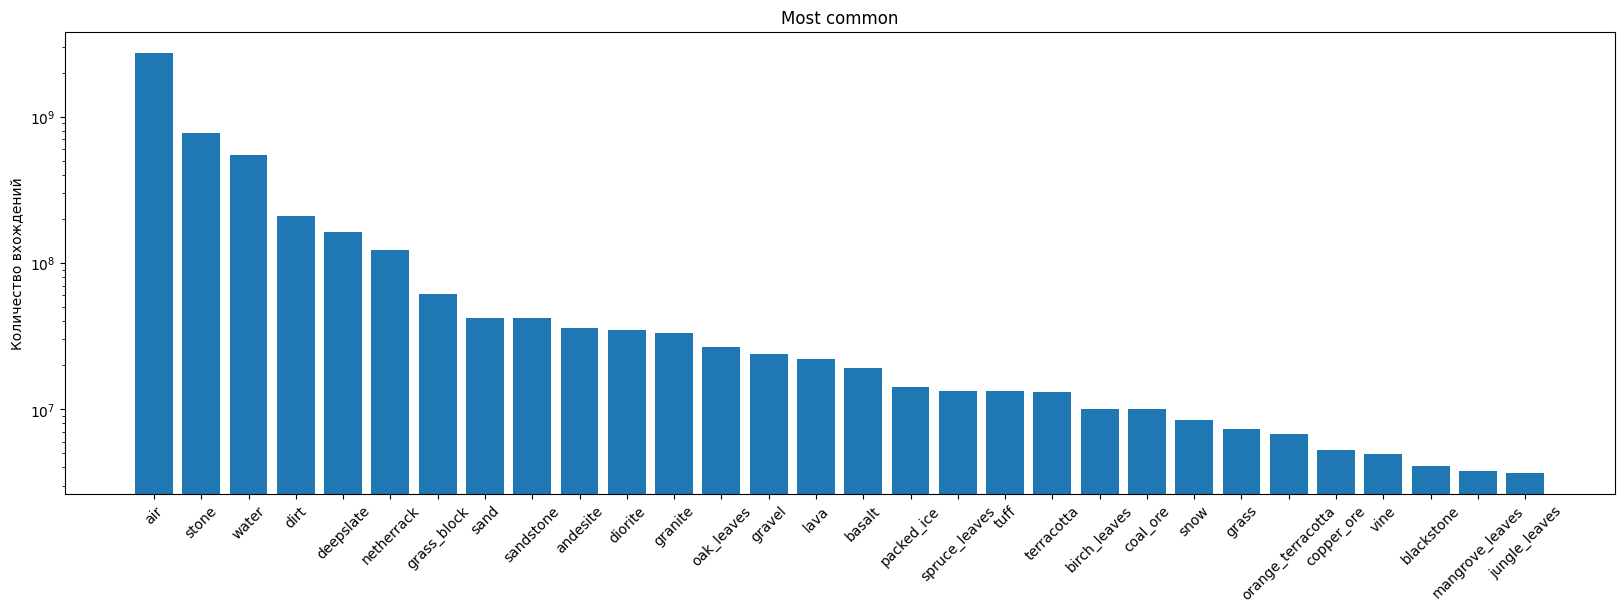

In [5]:
import numpy as np

def show_top_statistics(statistics, limit, reversed=False, nonzero=False, ax=None, title=""):
    data = sorted(statistics, key=lambda x: -x[1])

    if nonzero:
        data = [item for item in data if item[1] != 0]

    if reversed:
        data = data[-limit:]
    else:
        data = data[:limit]


    names = [item[0][item[0].index(":") + 1:] for item in data]
    values = [item[1] for item in data]

    ax.bar(np.arange(len(names)), values)
    ax.set_xticks(np.arange(len(names)), names, rotation=45)
    ax.set_title(title)
    ax.set_ylabel("Количество вхождений")
    ax.set_yscale("log")

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# show_top_statistics(statistics, 300, reversed=True, nonzero=False, ax=ax[0], title="Least common")
# show_top_statistics(statistics, 30, reversed=True, nonzero=True, ax=ax, title="Least common (ненулевые вхождения)")
show_top_statistics(statistics, 30, reversed=False, nonzero=False, ax=ax, title="Most common")

In [6]:
len(values)

478

In [7]:
print(values.max())
print(values.min())
print(values.mean())
print(values.median())

tensor(2.7382e+09)
tensor(1.)
tensor(10637638.)
tensor(2036.)


tensor(10.)
tensor(0.2283)
tensor(2.8928)
tensor(2.2550)


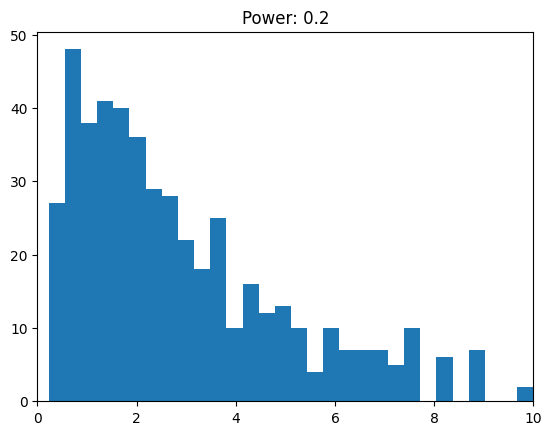

In [24]:
def make_class_weights(values, power=0.3, eps=1e-5):
    values = values.float()
    max_count = values.max()
    
    weights = (max_count / (values + eps)) ** power
    weights = weights / weights.max() * 9.9   # редчайшие классы -> 10
    return weights + 0.1

power = 0.2
w = make_class_weights(values, power=power)
print(w.max())
print(w.min())
print(w.mean())
print(w.median())
plt.hist(w, bins=30)
plt.xlim([0,10])
# plt.xscale("log")
# plt.xlim([0,2])
plt.title(f"Power: {power}");

tensor(1.0100)
tensor(0.0144)
tensor(0.2327)
tensor(0.1587)


In [ ]:
import torch

result = torch.nn.functional.softmax(values.log1p(), dim=0)

In [125]:
print(result.max())
print(result.min())
print(result.mean())
print(result.median())

tensor(0.5359)
tensor(3.9333e-10)
tensor(0.0021)
tensor(4.0257e-07)


In [138]:
print(torch.exp(1 / values).max())
print(torch.exp(1 / values).min())
print(torch.exp(1 / values).mean())
print(torch.exp(1 / values).median())

tensor(2.7183)
tensor(1.)
tensor(1.0411)
tensor(1.0005)


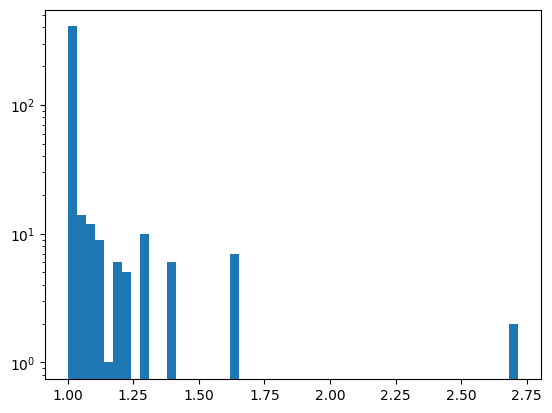

In [139]:
plt.hist(torch.exp(1 / values), bins=50, log=True);

In [126]:
# print(values.log1p().max())
# print(values.log1p().min())
# print(values.log1p().mean())
# print(values.log1p().median())

In [91]:
result2 = torch.log(1 / values.log1p())

In [92]:
print(result2.max())
print(result2.min())
print(result2.mean())
print(result2.median())

tensor(0.3665)
tensor(-3.0785)
tensor(-1.8967)
tensor(-2.0313)


In [112]:
w = ((result2 - result2.min()) / (result2.max() - result2.min())) * 3 + 0.1

In [113]:
print(w.max())
print(w.min())
print(w.mean())
print(w.median())

tensor(3.1000)
tensor(0.1000)
tensor(1.1291)
tensor(1.0119)


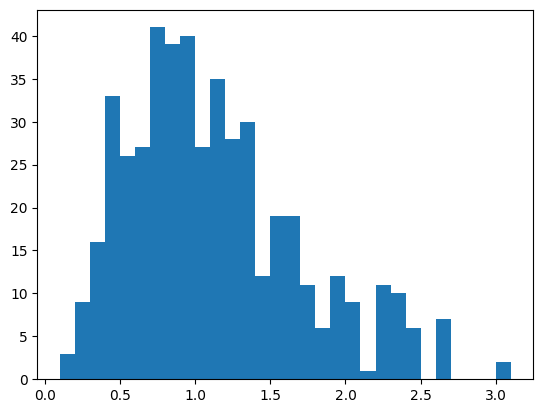

In [119]:
plt.hist(w, bins=30);

In [74]:
len(w)

479

In [75]:
torch.sum(w > 0.5)

tensor(9)

Статистики по abfielder

In [ ]:
import os
from pathlib import Path
import amulet
import json
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter
from logging import Logger
import numpy as np
import gc

random.seed(1984)
np.random.seed(1984)

with open("../block_data/filtered_blocks.json") as f:
    filtered_blocks = json.load(f)


blocks_counter = Counter()
non_existing_blocks_fraction = []

directory = Path("../../data/web_data/abfielder_schem_all")

shapes = []

files = os.listdir(directory)
np.random.shuffle(files)

limit = len(files)

success_count = 0
for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = directory / file
    mb = os.path.getsize(path) / 1024**2
    if mb > 15:
        continue
    try:
        non_existing_blocks_count = 0
        construction = amulet.load_level(str(path))
        dimension = construction.dimensions[0]
        selection = construction.bounds(dimension)
        bounds_array = selection.bounds_array
        shape = np.abs(bounds_array[0] - bounds_array[1])

        for coords in selection.blocks:
            block = construction.get_block(*coords, dimension).base_name
            if f"minecraft:{block}" in filtered_blocks:
                blocks_counter[block] += 1
            else:
                blocks_counter["air"] += 1
                non_existing_blocks_count += 1
                

        shapes.append(shape[None, :])
        non_existing_blocks_fraction.append(non_existing_blocks_count / np.prod(shape))
        success_count += 1
        construction.close()

        del construction
        gc.collect()
    except Exception as e:
        print(f"Error: {e}\nFile: {file}")
        continue

shapes = np.concatenate(shapes, axis=0)

In [5]:
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

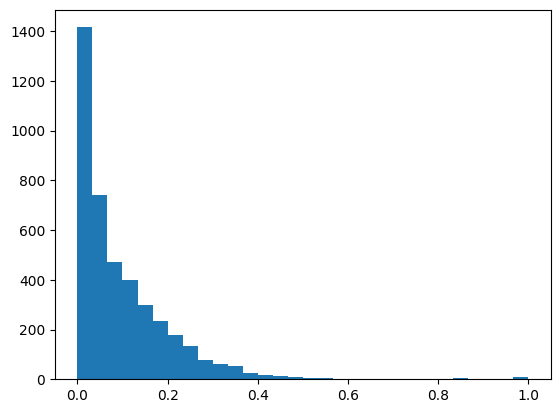

In [6]:
import matplotlib.pyplot as plt

plt.hist(non_existing_blocks_fraction, bins=30);

In [7]:
print(f"Successfully opened: {success_count} / {limit} schematics")
print(f"Allowed size schematics: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1))}")
print(f"Schematics with less than 10% of non-existing blocks: {np.sum(non_existing_blocks_fraction < 0.1)}")
print(f"Final schematics count: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1) * (non_existing_blocks_fraction < 0.1))}")

Successfully opened: 4176 / 4288 schematics
Allowed size schematics: 2262
Schematics with less than 10% of non-existing blocks: 2626
Final schematics count: 1255


In [8]:
print(f"Min x,y,z: {shapes.min(axis = 0)}")
print(f"Max x,y,z: {shapes.max(axis = 0)}")
print(f"Mean x,y,z: {shapes.mean(axis = 0)}")
print(f"Median x,y,z: {np.median(shapes,axis=0)}")

Min x,y,z: [0 0 0]
Max x,y,z: [1542 2047 1786]
Mean x,y,z: [48.51532567 41.5572318  49.0651341 ]
Median x,y,z: [25. 20. 25.]


Min x,y,z: [8 8 8]

Max x,y,z: [701 384 802]

Mean x,y,z: [55.99367089 48.39389427 55.95085629]

Median x,y,z: [34. 30. 33.]

In [9]:
volumes: np.ndarray = np.prod(shapes, axis=1)

print(f"Min Volume: {volumes.min()}")
print(f"Max Volume: {volumes.max()}")
print(f"Mean Volume: {volumes.mean()}")
print(f"Median Volume: {np.median(volumes)}")

Min Volume: 0
Max Volume: 455938560
Mean Volume: 1376234.365421456
Median Volume: 12784.0


In [10]:
print(f"Uniqie blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

print(f"20 Least common:")
minus_counter = Counter({key: -value for key, value in blocks_counter.items()})
print(*minus_counter.most_common(20), sep="\n")


Uniqie blocks: 300
Total amount: 5747154710
20 Most common:
('air', 5295093547)
('stone', 213271990)
('sand', 28463741)
('dirt', 20398867)
('water', 17663028)
('deepslate', 14248909)
('obsidian', 14216256)
('gravel', 13660743)
('andesite', 13396594)
('mud', 11950297)
('diorite', 10141042)
('granite', 9603180)
('sandstone', 6908174)
('quartz_block', 6886077)
('cobblestone', 6111901)
('grass_block', 5905001)
('smooth_quartz', 3967112)
('stone_bricks', 3790424)
('crying_obsidian', 2606963)
('blackstone', 2313825)
20 Least common:
('stripped_bamboo_block', -1)
('candle_cake', -7)
('cherry_planks', -13)
('bamboo_block', -14)
('calibrated_sculk_sensor', -21)
('cherry_wood', -40)
('pitcher_crop', -61)
('cherry_log', -105)
('stripped_cherry_log', -129)
('sculk_shrieker', -296)
('conduit', -321)
('hanging_roots', -330)
('crimson_fungus', -336)
('torchflower', -358)
('carved_pumpkin', -373)
('weathered_copper', -395)
('respawn_anchor', -428)
('chorus_flower', -446)
('bamboo_sapling', -449)
('sus

In [6]:
import nbtlib
import os
import numpy as np
from tqdm.notebook import tqdm
from pathlib import Path
import gc

directory = Path("../../data/web_data/abfielder_schem_all")

shapes = []

files = os.listdir(directory)
np.random.shuffle(files)

limit = len(files)

success_count = 0
for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = directory / file
    mb = os.path.getsize(path) / 1024**2
    if mb > 15:
        continue
    try:
       
        construction = nbtlib.load(path)
        if "Schematic" in construction.keys():
            construction = construction["Schematic"]
        shape = np.array([construction["Width"], construction["Height"], construction["Length"]])
        shapes.append(shape[None, :])

        del construction
        gc.collect()
    except Exception as e:
        print(f"Error: {e}\nFile: {file}")
        continue

shapes = np.concatenate(shapes, axis=0)


  0%|          | 0/4288 [00:00<?, ?it/s]

Error: 'Width'
File: 2059.schem


In [10]:
np.prod(shapes == 0, axis=1).nonzero()

(array([2957, 4185]),)

In [11]:
files[2957]

'1478.schem'

In [12]:
files[4185]

'3399.schem'

# Статистика mcbuild

In [22]:
import io
import nbtlib

INFESTED = "minecraft:infested_"
AIR = "minecraft:air"

class _VarintIO:
    """"""

    ### --- Fields

    # Used for reading the int bits from a varint byte
    _INT_BITMASK = 0b0111_1111
    # Used for reading the continue bit in a byte, which is
    # the MSB, if one, we continue reading to the next byte.
    _CONTINUE_BITMASK = 0b1000_0000

    ### ---

    ### --- Public static methods

    """
    Reads and returns the next varint of a varint byte stream while making it advance.
    Note that the varint read is going to be positive I was too lazy
    """

    @staticmethod
    def readPositiveVarInt(stream: io.BytesIO) -> int:
        # Setup
        varint: int = 0
        positionInInt: int = 0

        # Going while we didn't finish reading the int
        while True:
            # Read the next byte of the stream
            currentByte = int.from_bytes(stream.read(1), "big", signed=False)
            # Add the int bits to our varint
            varint |= (currentByte & _VarintIO._INT_BITMASK) << positionInInt

            # If the continue bit is 0, then stop reading this int
            if (currentByte & _VarintIO._CONTINUE_BITMASK) == 0:
                break

            # If we are continuing, add 7 to the position in the int, since
            # in varints the int is separated in groups of 7 bits.
            positionInInt += 7

        return varint


def _initFromFile(schematicToLoadPath: str):
    # Get the schematic file as a nbt map
    schematicFile = nbtlib.load(schematicToLoadPath)
    fileBase = (
        schematicFile["Schematic"] if "Schematic" in schematicFile else schematicFile
    )

    ## Init the block palette
    filePalette = fileBase["Palette"]
    structureBlockPalette = {}

    for blockState, idTagInPalette in filePalette.items():
        idInPalette = int(idTagInPalette)
        structureBlockPalette[blockState] = idInPalette
        structureBlockPalette[idInPalette] = blockState
    # Nothing has been put inside the block palette, so we default init it.
    if len(structureBlockPalette) == 0:
        structureBlockPalette = {"minecraft:air": 0, 0: "minecraft:air"}
    # Set the free Id to the length of the block palette // 2 as each Id has 2 entries
    structureBlockPaletteFreeId = len(structureBlockPalette) // 2

    # -- Re process the block palette so that ID 0 is air
    # Put air inside the hashmap if it wasn't present yet.
    # used for future processing that's why it's not equal to 0
    if "minecraft:air" not in structureBlockPalette:
        structureBlockPalette["minecraft:air"] = structureBlockPaletteFreeId
        structureBlockPalette[structureBlockPaletteFreeId] = "minecraft:air"
        structureBlockPaletteFreeId += 1
    # If the current air ID isn't 0, switch it up with the
    # current 0 id, example:
    #   palette{0: black_wool, 1: air} will get switched to:
    #   palette{0: air, 1: black_wool}
    # And the byte ids will get processed afterwards
    beforeProcessingAirId = structureBlockPalette["minecraft:air"]
    airOldId = beforeProcessingAirId
    if beforeProcessingAirId != 0:
        beforeProcessingId0State = structureBlockPalette[0]
        # Pop the 0 id
        structureBlockPalette.pop(0)
        structureBlockPalette.pop(beforeProcessingId0State)
        # Pop the air id
        structureBlockPalette.pop(beforeProcessingAirId)
        structureBlockPalette.pop("minecraft:air")

        # Put the air at 0
        structureBlockPalette[0] = "minecraft:air"
        structureBlockPalette["minecraft:air"] = 0
        # Put the old currentId0State where air was
        structureBlockPalette[beforeProcessingAirId] = beforeProcessingId0State
        structureBlockPalette[beforeProcessingId0State] = beforeProcessingAirId

    ## Init the blockStates in _blockStates
    structureBlockStates: dict[tuple[int, int, int], int] = {}
    if "BlockData" in fileBase:
        # Get the necessary data for blockState loading
        fileBlockStatesIds = fileBase["BlockData"]
        blockStatesIds = bytearray(fileBlockStatesIds)
        schemOffset = (0, 0, 0)  # fileBase['Offset']
        # schemHeight = int(fileBase["Height"])  # y
        schemLength = int(fileBase["Length"])  # z
        schemWidth = int(fileBase["Width"])  # x

        # Variable so that we don't have to do a multiplication every iteration
        schemYSliceArea = schemWidth * schemLength

        if len(structureBlockPalette) < 128:
            # The amount of block states is less than 128, so each block is a byte,
            # so we use the old faster algorithm to load the structure

            for blockStateIndex, blockStateId in enumerate(blockStatesIds):
                # Process the blockStateId since the palette has been modified
                processedBlockStateId = blockStateId
                # -- Do le switcharoo, air new Id is 0 no matter what
                # If we refer to the old air Id, it means that we refer to air now
                # which is 0
                if blockStateId == airOldId:
                    processedBlockStateId = 0
                # If we refer to the old id at 0, we are referring to the new
                # content of the old air id spot
                if blockStateId == 0:
                    processedBlockStateId = airOldId

                # Since we processed the blockPalette so that air is 0, if the ID is 0
                # then skip, as we don't keep track of air blocks

                # Getting the coordinates in the schem not shifted yet
                blockStateSchemY = blockStateIndex // schemYSliceArea
                blockStateSchemZ = (blockStateIndex % schemYSliceArea) // schemWidth
                blockStateSchemX = blockStateIndex % schemWidth

                # Shift the coordinates so that the blocks are back in their right position
                realY = blockStateSchemY + schemOffset[1]
                realZ = blockStateSchemZ + schemOffset[2]
                realX = blockStateSchemX + schemOffset[0]

                # Place the block
                structureBlockStates[(realX, realY, realZ)] = processedBlockStateId

        else:
            # The palette contains more (or equal) than 128 entries, so we use
            # the varint algorithm

            # Put the blockState bytes into a BytesIO for a stream
            blockStatesIdStream = io.BytesIO(blockStatesIds)

            # Setup before loopin woo
            blockStateIndex = 0

            # We loopin bois
            while blockStatesIdStream.tell() < len(blockStatesIds):
                # Get the next varint of the stream
                blockStateId = _VarintIO.readPositiveVarInt(blockStatesIdStream)
                # From there, use the normal old algorithm, cba to put it in
                # a method lmfao

                # ===
                # Process the blockStateId since the palette has been modified
                processedBlockStateId = blockStateId
                # -- Do le switcharoo, air new Id is 0 no matter what
                # If we refer to the old air Id, it means that we refer to air now
                # which is 0
                if blockStateId == airOldId:
                    processedBlockStateId = 0
                # If we refer to the old id at 0, we are referring to the new
                # content of the old air id spot
                if blockStateId == 0:
                    processedBlockStateId = airOldId

                # Since we processed the blockPalette so that air is 0, if the ID is 0
                # then skip, as we don't keep track of air blocks

                # Getting the coordinates in the schem not shifted yet
                blockStateSchemY = blockStateIndex // schemYSliceArea
                blockStateSchemZ = (blockStateIndex % schemYSliceArea) // schemWidth
                blockStateSchemX = blockStateIndex % schemWidth

                # Shift the coordinates so that the blocks are back in their right position
                realY = blockStateSchemY + schemOffset[1]
                realZ = blockStateSchemZ + schemOffset[2]
                realX = blockStateSchemX + schemOffset[0]

                # Place the block
                structureBlockStates[(realX, realY, realZ)] = processedBlockStateId
                # ===

                # -- Increment block state index as we're done registering that block
                blockStateIndex += 1

    return structureBlockStates, structureBlockPalette


def parse_block(block: str) -> tuple[str, dict[str, str]]:
    """
    block : str
        A string representing minecraft block with its attributes.
        Example: minecraft:water[level=0]
    """
    idx = block.find("[")
    if idx != -1:
        block, attr_data = block[:idx], block[idx + 1 : -1]
    else:
        return block, {}

    attr_data = attr_data.split(",")
    attr_dict = {}
    for item in attr_data:
        attr, value = item.split("=")
        attr_dict[attr] = value
    return block, attr_dict


def block_to_idx(block: str, block2idx: dict[str, int]) -> int:
    """
    A function that matches the block type and its index,
    considering filtered blocks. Infested blocks are treated
    as their normal variant. Other filtered blocks are treated
    as air blocks.

    Args:

    block : str
        A string representing minecraft block type (ex. 'minecraft:stone')
    block2idx : dict
        A dict for matching block type and its index
    """
    not_found = False

    if block not in block2idx:
        if block == "minecraft:sign":
            block = "minecraft:oak_sign"
        elif block == "minecraft:wall_sign":
            block = "minecraft:oak_wall_sign"
        elif block == "minecraft:grass_path":
            block = "minecraft:dirt_path"
        elif block.startswith(INFESTED):
            block = "minecraft:" + block[len(INFESTED) :]
        else:
            block = AIR
            not_found = True
    return block, block2idx[block], not_found

In [24]:
import os
from pathlib import Path
import json
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter
from logging import Logger
import numpy as np
import gc
import nbtlib

exclude = [
    "minecraft:wall_sign",
    "minecraft:sign",
    "minecraft:grass_path"
]


random.seed(1984)
np.random.seed(1984)

with open("../block_data/filtered_blocks.json") as f:
    filtered_blocks = json.load(f)

with open("../block_data/blocks.json") as f:
    all_blocks = json.load(f)

with open("../block_data/block2idx.json") as f:
    block2idx = json.load(f)


blocks_counter = Counter()
non_existing_blocks_fraction = []

directory = Path("../../data/web_data/mcbuild_schem")

shapes = []

files = os.listdir(directory)

limit = len(files)

success_count = 0
for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = directory / file
    mb = os.path.getsize(path) / 1024**2
    if mb > 15:
        continue
    try:
        non_existing_blocks_count = 0
        schem = nbtlib.load(str(path))
        width, height, length = schem["Width"], schem["Height"], schem["Length"]
        shape = np.array([width, height, length])

        del schem

        # проверка по размерам
        if not(np.prod(shape <= 64, axis=0) * np.prod(shape >= 5, axis=0)):
            continue

        coord2byte, palette = _initFromFile(str(path))

        attributes = {}

        for x, y, z in coord2byte:
            block_byte = coord2byte[(x, y, z)]
            block = palette[block_byte]

            block, attr_dict = parse_block(block)  # str, dict
            block, block_idx, not_found = block_to_idx(block, block2idx)  # str, int
            blocks_counter[block] += 1
            if not_found:
                non_existing_blocks_count += 1
                
                

        

        shapes.append(shape[None, :])
        non_existing_blocks_fraction.append(non_existing_blocks_count / np.prod(shape))
        success_count += 1
        gc.collect()
    except Exception as e:
        print(f"Error: {e}\nFile: {file}")
        continue

shapes = np.concatenate(shapes, axis=0)
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

  0%|          | 0/7887 [00:00<?, ?it/s]

In [25]:
print(f"Total opened: {limit} schematics")
print(f"Allowed size schematics: {len(shapes)}")
print(f"Schematics with less than 10% of non-existing blocks: {np.sum(non_existing_blocks_fraction < 0.1)}")
print(f"Final schematics count: {np.sum(non_existing_blocks_fraction < 0.1)}")

Total opened: 7887 schematics
Allowed size schematics: 4444
Schematics with less than 10% of non-existing blocks: 4417
Final schematics count: 4417


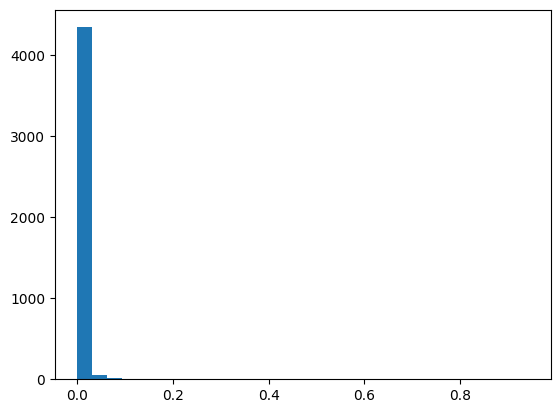

In [30]:
import matplotlib.pyplot as plt

plt.hist(non_existing_blocks_fraction, bins=30);

In [27]:
print(f"Min x,y,z: {shapes.min(axis = 0)}")
print(f"Max x,y,z: {shapes.max(axis = 0)}")
print(f"Mean x,y,z: {shapes.mean(axis = 0)}")
print(f"Median x,y,z: {np.median(shapes,axis=0)}")

Min x,y,z: [5 5 5]
Max x,y,z: [64 64 64]
Mean x,y,z: [24.73087309 20.86116112 24.78735374]
Median x,y,z: [21. 17. 21.]


In [28]:
volumes: np.ndarray = np.prod(shapes, axis=1)

print(f"Min Volume: {volumes.min()}")
print(f"Max Volume: {volumes.max()}")
print(f"Mean Volume: {volumes.mean()}")
print(f"Median Volume: {np.median(volumes)}")

Min Volume: 125
Max Volume: 250047
Mean Volume: 19786.307380738075
Median Volume: 8291.5


In [29]:
print(f"Uniqie blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

print(f"20 Least common:")
minus_counter = Counter({key: -value for key, value in blocks_counter.items()})
print(*minus_counter.most_common(20), sep="\n")


Uniqie blocks: 421
Total amount: 87930350
20 Most common:
('minecraft:air', 70284305)
('minecraft:stone', 2012373)
('minecraft:dirt', 1907174)
('minecraft:stone_bricks', 891890)
('minecraft:grass_block', 890874)
('minecraft:quartz_block', 885333)
('minecraft:water', 529394)
('minecraft:oak_planks', 512715)
('minecraft:cobblestone', 419634)
('minecraft:sandstone', 399848)
('minecraft:glass', 327997)
('minecraft:iron_block', 307907)
('minecraft:spruce_planks', 297203)
('minecraft:stone_slab', 282749)
('minecraft:sand', 258737)
('minecraft:white_wool', 244386)
('minecraft:oak_log', 225237)
('minecraft:oak_leaves', 215931)
('minecraft:birch_planks', 211993)
('minecraft:quartz_slab', 168977)
20 Least common:
('minecraft:acacia_sapling', -1)
('minecraft:orange_concrete_powder', -1)
('minecraft:magenta_concrete_powder', -2)
('minecraft:lime_concrete_powder', -2)
('minecraft:black_concrete_powder', -11)
('minecraft:light_blue_shulker_box', -13)
('minecraft:dark_oak_sapling', -13)
('minecraft:b